## Passo 1: Importar Bibliotecas Necessárias

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Definir o estilo dos gráficos para melhor visualização
sns.set(style="whitegrid")


## Passo 2: Carregar o Conjunto de Dados

In [61]:
# Carregar o conjunto de dados de treino
url_train = 'https://github.com/Magno-Rodrigues/Kaggle/blob/main/titanic_model/train.csv?raw=true'
df_train = pd.read_csv(url_train)

# Carregar o conjunto de dados de teste
url_test = 'https://github.com/Magno-Rodrigues/Kaggle/blob/main/titanic_model/test.csv?raw=true'
df_test = pd.read_csv(url_test)

# Exibir as primeiras linhas do conjunto de dados para entender sua estrutura
display (df_train.head(), df_test.head())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Matriz de correlação entre as variáveis

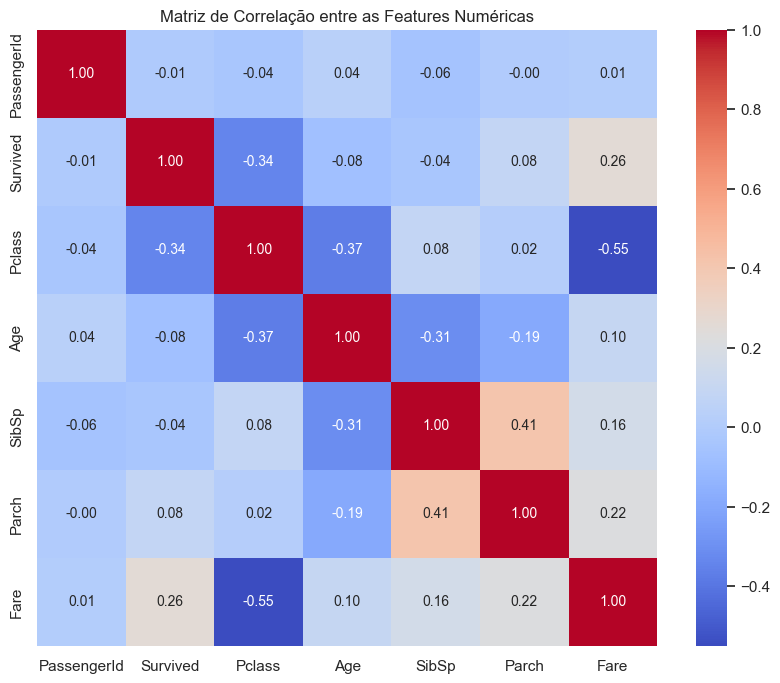

In [62]:
# Selecionar apenas features numéricas e relevantes para a matriz de correlação
numeric_features = df_train.select_dtypes(include=['int64', 'float64'])

# Plotar a matriz de correlação
plt.figure(figsize=(10, 8))
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação entre as Features Numéricas')
plt.show()


## Passo 3: Visão Geral dos Dados

In [63]:
# Exibir informações básicas sobre o conjunto de dados de treino
df_train.info()

# Mostrar estatísticas resumidas para as colunas numéricas
df_train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Passo 4: Tratamento de Valores Ausentes

In [64]:
# Verificar valores ausentes
valores_ausentes = df_train.isnull().sum()

# Exibir colunas com valores ausentes
valores_ausentes[valores_ausentes > 0]


Age         177
Cabin       687
Embarked      2
dtype: int64

## Passo 5: Visualização dos Dados

5.1: Distribuição das Características Numéricas

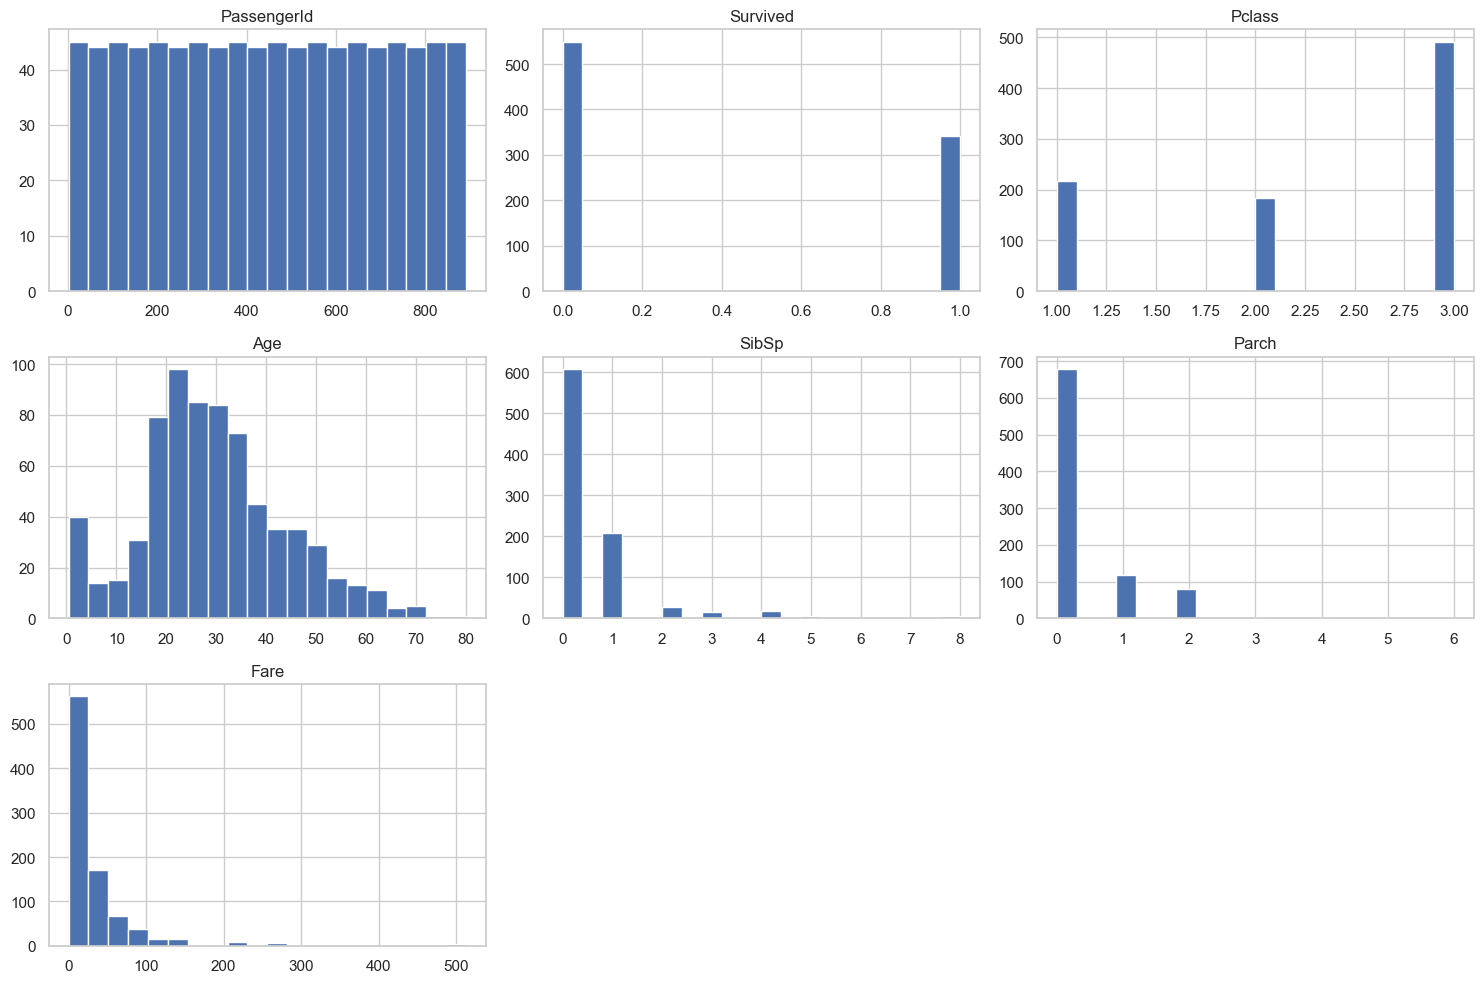

In [65]:
# Plotar histogramas para características numéricas
df_train.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()


5.2: Distribuição das Características Categóricas

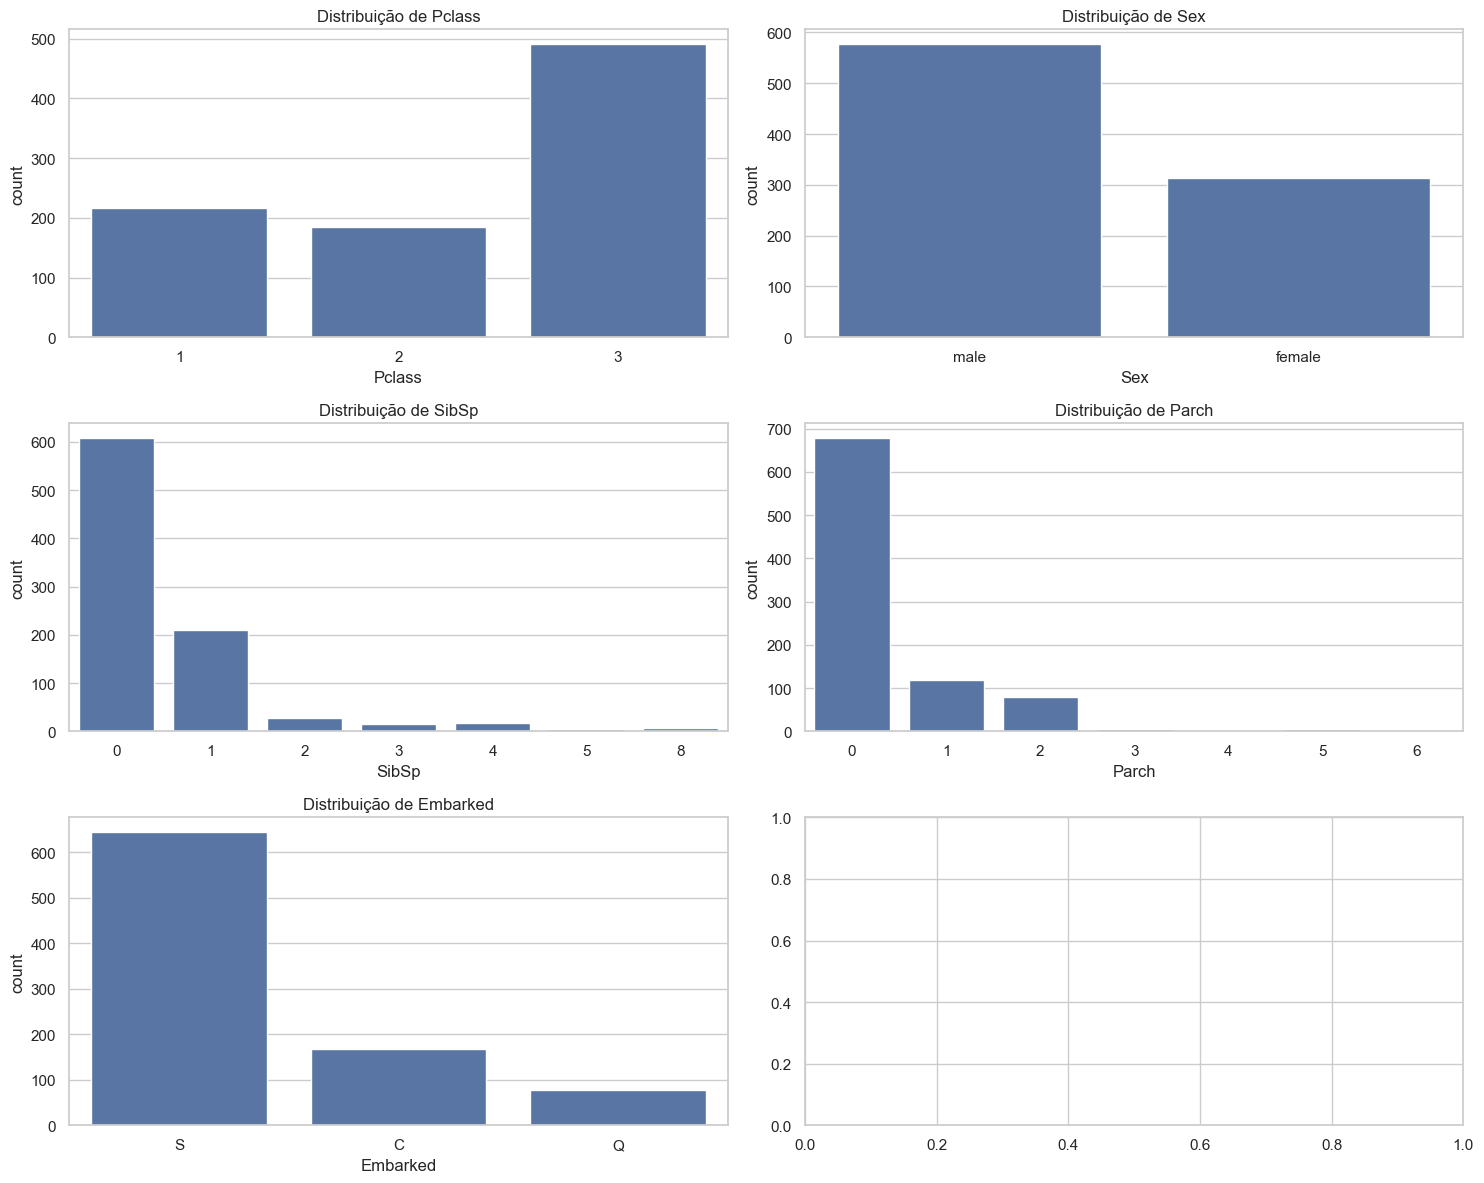

In [66]:
# Suprimir FutureWarnings específicos
warnings.simplefilter(action='ignore', category=FutureWarning)

# Plotar gráficos de contagem para características categóricas
caracteristicas_categoricas = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, cat_feature in zip(axes, caracteristicas_categoricas):
    sns.countplot(data=df_train, x=cat_feature, ax=ax)
    ax.set_title(f'Distribuição de {cat_feature}')

plt.tight_layout()
plt.show()


5.3: Taxa de Sobrevivência por Características Categóricas

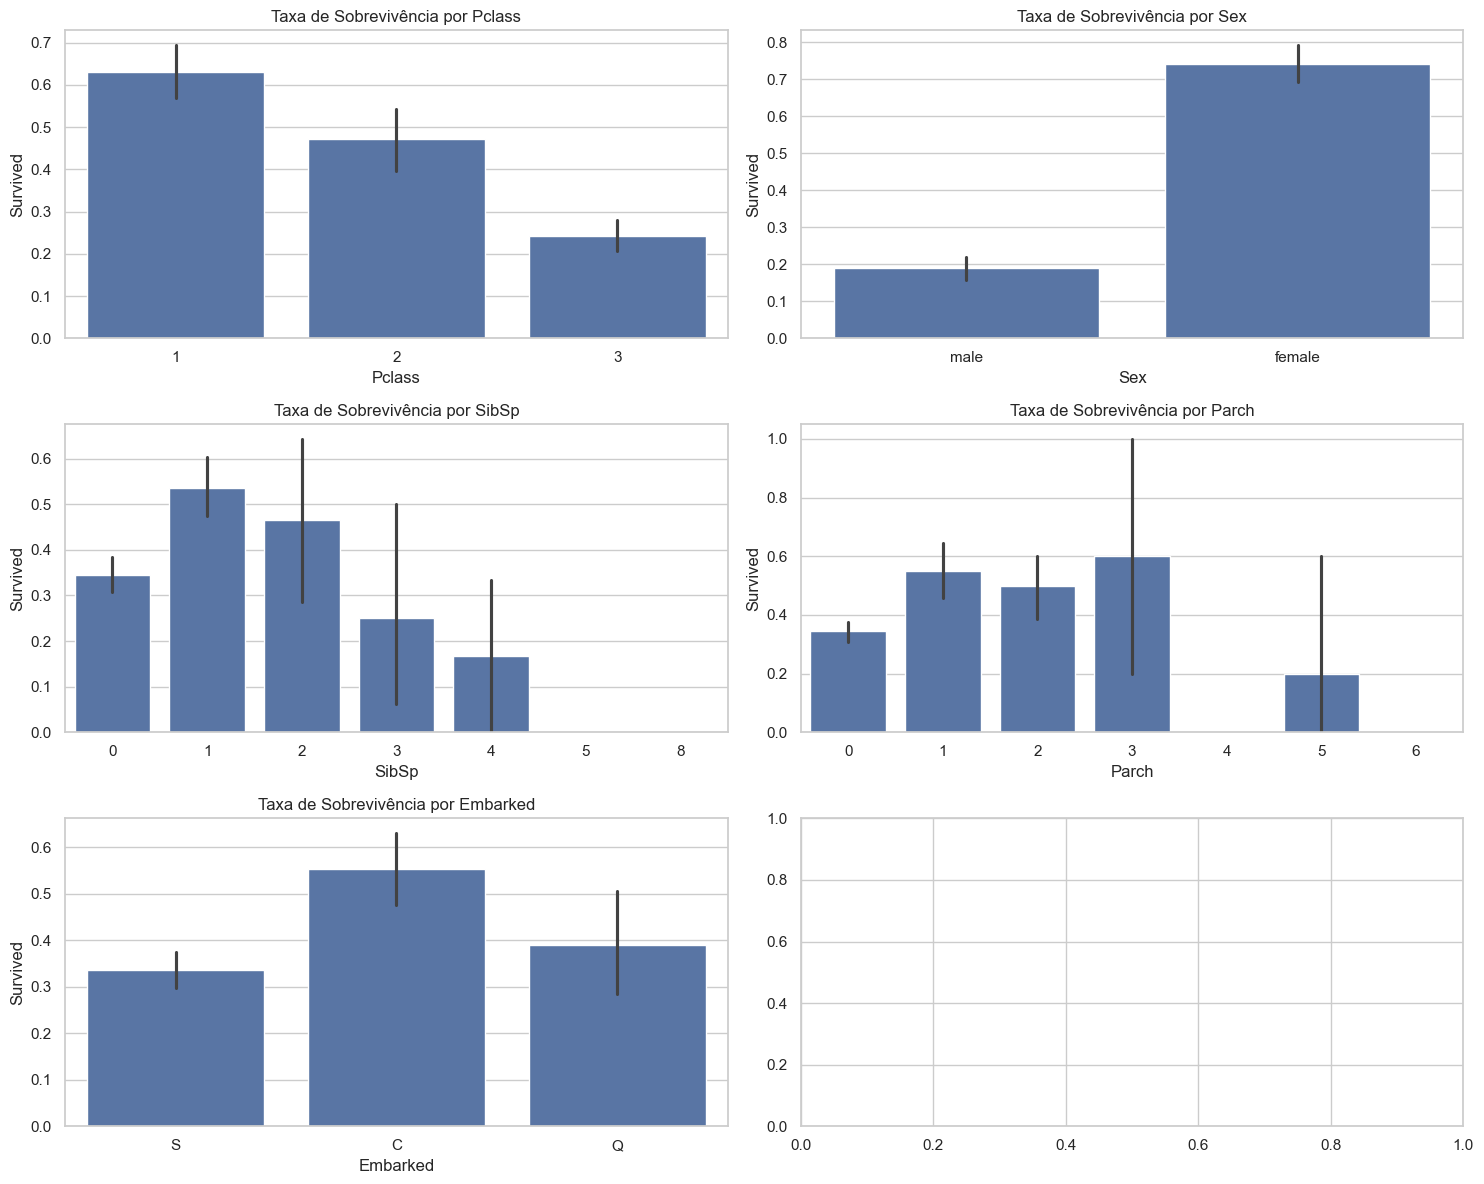

In [67]:
# Suprimir FutureWarnings específicos
warnings.simplefilter(action='ignore', category=FutureWarning)

# Plotar taxa de sobrevivência por características categóricas
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, cat_feature in zip(axes, caracteristicas_categoricas):
    sns.barplot(data=df_train, x=cat_feature, y='Survived', ax=ax)
    ax.set_title(f'Taxa de Sobrevivência por {cat_feature}')

plt.tight_layout()
plt.show()


## Passo 6: Engenharia de Características

In [68]:
# Extrair título do nome
df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Verificar a distribuição de títulos
display(df_train['Title'].value_counts())

# Mapear títulos raros para 'Rare'
rare_titles = df_train['Title'].value_counts()[df_train['Title'].value_counts() < 10].index
df_train['Title'] = df_train['Title'].replace(rare_titles, 'Rare')
df_test['Title'] = df_test['Title'].replace(rare_titles, 'Rare')

# Mapear os títulos para números
title_mapping = {'Mr': 1, 'Mrs': 2, 'Miss': 3, 'Master': 4, 'Rare': 5}
df_train['Title'] = df_train['Title'].map(title_mapping)
df_test['Title'] = df_test['Title'].map(title_mapping)

# Verificar o dataframe atualizado com a columa Title inserida
# display(df_train.head())




# Preencher valores ausentes para 'Embarked' com a moda
df_train['Embarked'].fillna(df_train['Embarked'].mode()[0], inplace=True)
df_test['Embarked'].fillna(df_test['Embarked'].mode()[0], inplace=True)

# Preencher valores ausentes para 'Age' com a mediana
df_train['Age'].fillna(df_train['Age'].median(), inplace=True)
df_test['Age'].fillna(df_test['Age'].median(), inplace=True)

# Preencher valores ausentes para 'Fare' com a mediana
df_test['Fare'].fillna(df_test['Fare'].median(), inplace=True)

# Remover a coluna 'Cabin' devido a muitos valores ausentes
df_train.drop(columns=['Cabin'], inplace=True)
df_test.drop(columns=['Cabin'], inplace=True)

# Converter características categóricas para numéricas
df_train = pd.get_dummies(df_train, columns=['Sex', 'Embarked'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Sex', 'Embarked'], drop_first=True)

# Alinhar df_test com df_train para ter as mesmas colunas
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

# Remover a coluna 'Survived' de df_test (não está presente no conjunto de teste original)
df_test.drop(columns=['Survived'], inplace=True)

# Remover colunas 'Name' e 'Ticket' que não são usadas no modelo
df_train.drop(columns=['Name', 'Ticket'], inplace=True)
df_test.drop(columns=['Name', 'Ticket'], inplace=True)

# Exibir as primeiras linhas do conjunto de dados processado
display(df_train.info(), df_train.head(), df_test.head())


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          714 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Title        891 non-null    int64  
 8   Sex_male     891 non-null    bool   
 9   Embarked_Q   891 non-null    bool   
 10  Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(2), int64(6)
memory usage: 58.4 KB


None

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Title,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,1,True,False,True
1,2,1,1,38.0,1,0,71.2833,2,False,False,False
2,3,1,3,26.0,0,0,7.9250,3,False,False,True
3,4,1,1,35.0,1,0,53.1000,2,False,False,True
4,5,0,3,35.0,0,0,8.0500,1,True,False,True


,PassengerId,Pclass,Age,SibSp,Parch,Fare,Title,Sex_male,Embarked_Q,Embarked_S
0,892,3,34.5,0,0,7.8292,1.0,True,True,False
1,893,3,47.0,1,0,7.0000,2.0,False,False,True
2,894,2,62.0,0,0,9.6875,1.0,True,True,False
3,895,3,27.0,0,0,8.6625,1.0,True,False,True
4,896,3,22.0,1,1,12.2875,2.0,False,False,True


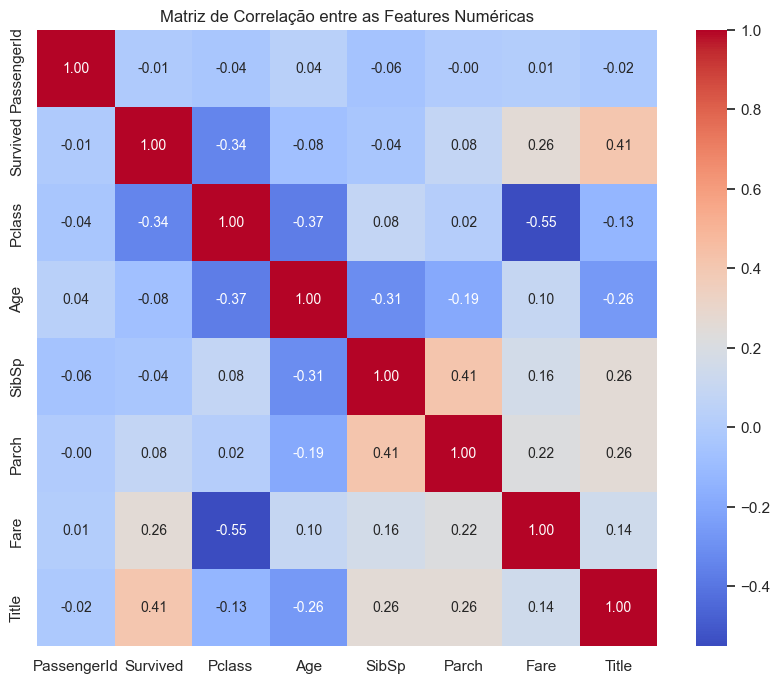

In [69]:
# Selecionar apenas features numéricas e relevantes para a matriz de correlação
numeric_features = df_train.select_dtypes(include=['int64', 'float64'])

# Plotar a matriz de correlação
plt.figure(figsize=(10, 8))
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação entre as Features Numéricas')
plt.show()

## Passo 7: Dividir os Dados em Conjuntos de Treino e Teste

In [70]:
from sklearn.model_selection import train_test_split

# Definir características e variável alvo
X = df_train.drop(columns=['Survived'])
y = df_train['Survived']

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Passo 8: Treinar um Modelo de Machine Learning

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Inicializar o modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinar o modelo
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)


## Passo 9: Avaliar o Modelo

In [72]:
# Calcular a acurácia
accuracy = accuracy_score(y_test, y_pred)

# Exibir matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Exibir relatório de classificação
class_report = classification_report(y_test, y_pred)

display(accuracy, conf_matrix, class_report)


0.8379888268156425

array([[92, 13],
       [16, 58]])

'              precision    recall  f1-score   support\n\n           0       0.85      0.88      0.86       105\n           1       0.82      0.78      0.80        74\n\n    accuracy                           0.84       179\n   macro avg       0.83      0.83      0.83       179\nweighted avg       0.84      0.84      0.84       179\n'

## Passo 10: Visualizar a Matriz de Confusão

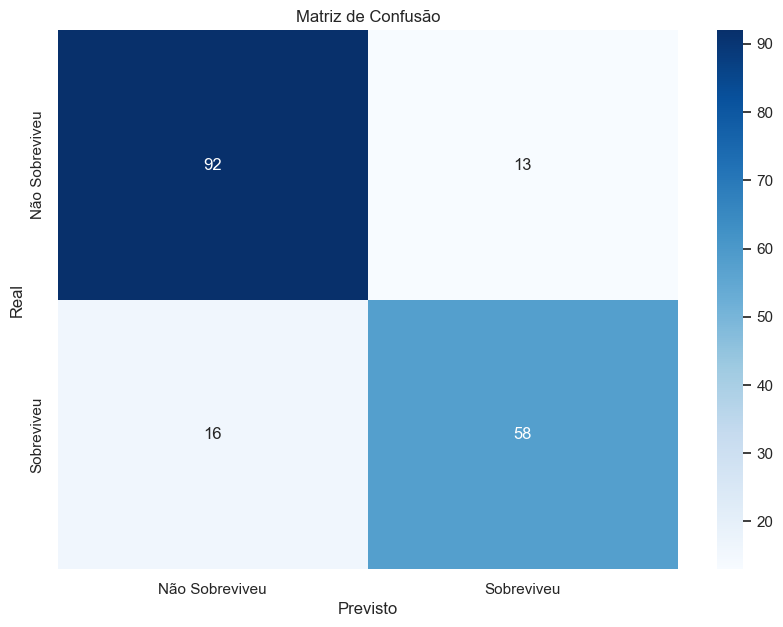

In [73]:
# Plotar a matriz de confusão
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Sobreviveu', 'Sobreviveu'], yticklabels=['Não Sobreviveu', 'Sobreviveu'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()


## Passo 11: Dados Escalados

In [74]:
from sklearn.preprocessing import StandardScaler

# Inicializar o scaler
scaler = StandardScaler()

# Ajustar e transformar os dados de treino, e transformar os dados de teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
df_test_scaled = scaler.transform(df_test)



In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Inicializar o scaler
scaler = StandardScaler()

# Ajustar e transformar os dados de treino, e transformar os dados de teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
df_test_scaled = scaler.transform(df_test)

# Tratar valores ausentes nos dados de teste escalados usando imputação simples
imputer = SimpleImputer(strategy='median')  # Usando a mediana para imputação
X_test_scaled = imputer.fit_transform(X_test_scaled)
df_test_scaled = imputer.transform(df_test_scaled)


## Passo 12: Treinar o Modelo com Dados Escalados

In [76]:
# Treinar o modelo com dados escalados
model.fit(X_train_scaled, y_train)

# Fazer previsões com dados escalados
y_pred_scaled = model.predict(X_test_scaled)


## Passo 13: Avaliar o Modelo com Dados Escalados

In [77]:
# Calcular a acurácia com dados escalados
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

# Exibir matriz de confusão com dados escalados
conf_matrix_scaled = confusion_matrix(y_test, y_pred_scaled)

# Exibir relatório de classificação com dados escalados
class_report_scaled = classification_report(y_test, y_pred_scaled)

accuracy_scaled, conf_matrix_scaled, class_report_scaled


(0.8491620111731844,
 array([[93, 12],
        [15, 59]]),
 '              precision    recall  f1-score   support\n\n           0       0.86      0.89      0.87       105\n           1       0.83      0.80      0.81        74\n\n    accuracy                           0.85       179\n   macro avg       0.85      0.84      0.84       179\nweighted avg       0.85      0.85      0.85       179\n')

## Passo 14: Visualizar a Matriz de Confusão para Dados Escalados

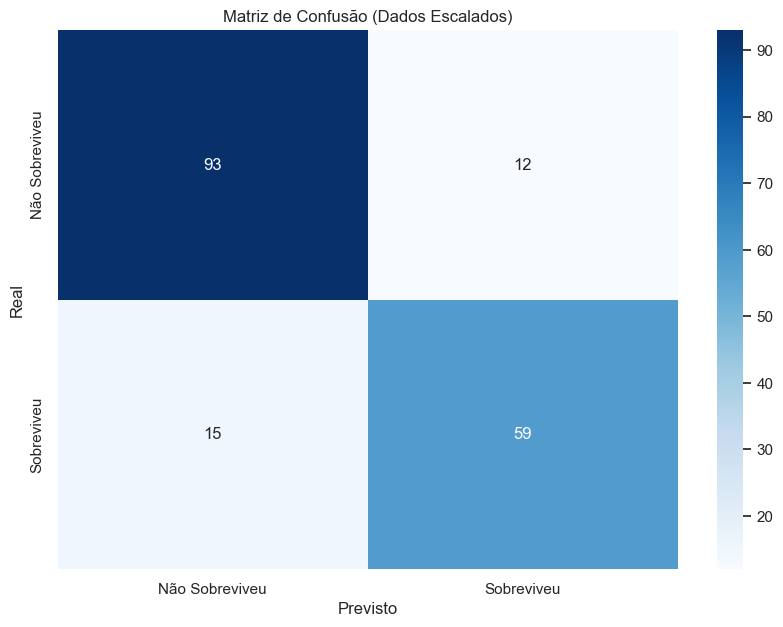

In [78]:
# Plotar a matriz de confusão para dados escalados
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_scaled, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Sobreviveu', 'Sobreviveu'], yticklabels=['Não Sobreviveu', 'Sobreviveu'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Dados Escalados)')
plt.show()


##  Passo 15: Melhorar a Acurácia com Diferentes Modelos

## Passo 16: Importar Bibliotecas Necessárias

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Passo 17: Treinar e Avaliar Diferentes Modelos

In [80]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    return accuracy, conf_matrix, class_report


## Passo 18: Inicializar e Avaliar Cada Modelo

- Regressão Logística

In [81]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Corrigir NaN
imputer = SimpleImputer(strategy='median')

X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

# Modelo
log_reg = LogisticRegression(max_iter=1000, random_state=42)

accuracy_log_reg, conf_matrix_log_reg, class_report_log_reg = evaluate_model(
    log_reg,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)


- Máquina de Vetores de Suporte (SVM)

In [82]:
svm = SVC(kernel='linear', random_state=42)
accuracy_svm, conf_matrix_svm, class_report_svm = evaluate_model(svm, X_train_scaled, y_train, X_test_scaled, y_test)


- Classificador de Gradiente Boosting

In [83]:
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)
accuracy_gbc, conf_matrix_gbc, class_report_gbc = evaluate_model(gbc, X_train_scaled, y_train, X_test_scaled, y_test)


-  Classificador XGBoost

In [84]:
xgboost = xgb.XGBClassifier(n_estimators=100, random_state=42)
accuracy_xgb, conf_matrix_xgb, class_report_xgb = evaluate_model(xgboost, X_train_scaled, y_train, X_test_scaled, y_test)


## Passo 19: Comparar o Desempenho dos Modelos

In [85]:
model_results = pd.DataFrame({
    'Model': ['Random Forest (Unscaled)', 'Random Forest (Scaled)', 'Logistic Regression', 'Support Vector Machine', 'Gradient Boosting Classifier', 'XGBoost Classifier'],
    'Accuracy': [accuracy, accuracy_scaled, accuracy_log_reg, accuracy_svm, accuracy_gbc, accuracy_xgb]
})

model_results


,Model,Accuracy
0,Random Forest (Unscaled),0.837989
1,Random Forest (Scaled),0.849162
2,Logistic Regression,0.782123
3,Support Vector Machine,0.782123
4,Gradient Boosting Classifier,0.804469
5,XGBoost Classifier,0.826816


## Passo 20: Criar um Gráfico Interativo Comparativo

In [86]:
import plotly.express as px

# Criar o gráfico de barras interativo com multi-seleção
fig = px.bar(
    model_results, 
    x='Model', 
    y='Accuracy', 
    title='Comparação de Modelos: Acurácia', 
    labels={'Accuracy': 'Acurácia', 'Model': 'Modelo'},
    color='Accuracy',
    color_continuous_scale='Viridis'
)

# Atualizar layout para habilitar multi-seleção
fig.update_layout(
    title="Comparação de Modelos: Acurácia",
    xaxis_title="Modelo",
    yaxis_title="Acurácia",
    clickmode='event+select'
)

# Habilitar multi-seleção
fig.update_traces(marker=dict(opacity=0.7), selector=dict(type='bar'))
fig.show()


## Passo 21: Criar Arquivos de Submissão para Cada Modelo

In [87]:
import warnings
warnings.filterwarnings('ignore')

# Função para criar o arquivo de submissão
def create_submission(model, X_test, submission_file):
    predictions = model.predict(X_test)
    submission = pd.DataFrame({
        'PassengerId': df_test['PassengerId'],
        'Survived': predictions
    })
    submission.to_csv(submission_file, index=False)

# Random Forest (Unscaled)
create_submission(model, df_test, 'submission_random_forest_unscaled.csv')

# Random Forest (Scaled)
model.fit(X_train_scaled, y_train)
create_submission(model, df_test_scaled, 'submission_random_forest_scaled.csv')

# Logistic Regression
log_reg.fit(X_train_scaled, y_train)
create_submission(log_reg, df_test_scaled, 'submission_logistic_regression.csv')

# Support Vector Machine
svm.fit(X_train_scaled, y_train)
create_submission(svm, df_test_scaled, 'submission_svm.csv')

# Gradient Boosting Classifier
gbc.fit(X_train_scaled, y_train)
create_submission(gbc, df_test_scaled, 'submission_gbc.csv')

# XGBoost Classifier
xgboost.fit(X_train_scaled, y_train)
create_submission(xgboost, df_test_scaled, 'submission_xgboost.csv')

